# Módulo 10 atividade 1

Uma instituição financeira quer conhecer melhor o perfil de renda de seus novos clientes para diversos fins, por exemplo, melhor dimensionar o limite de cartões de crédito dos novos clientes, sem necessariamente solicitar olerites ou documentações que impactem na experiência do seu cliente.

Para isto, conduziu um estudo com alguns clientes, comprovando suas rendas através de olerites e outros documentos, e pretende construir um modelo preditivo para esta renda com base em algumas variáveis que já possui em seu banco de dados.

As variáveis são intuitivas - note que há uma variável 'index' que é um identificador do cliente e que em geral o ```read_csv``` do pandas coloca também uma variável sequencial.

Estes dados estão no arquivo ```previsao_de_renda.csv```. Carregue-o em um *dataframe*.

1) Avalie a estrutura de correlação das variáveis quantitativas através de um gráfico de "matriz de dispersão" e através da avaliação gráfica da matriz de correlações. Veja se você identifica algum padrão interessante ou que te faça sentido.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
path = r'C:\Users\lucas\Documents\Mod_10\previsao_de_renda.csv'

In [35]:
previsao_renda = pd.read_csv(path)
previsao_renda.head()

,Unnamed: 0,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,mau,renda
0,0,2015-01-01,8682,F,False,True,1,Assalariado,Secundário,Casado,Casa,36,3.575342,3.0,False,3369.24
1,1,2015-01-01,12830,M,True,True,0,Empresário,Secundário,Casado,Casa,42,0.860274,2.0,False,6096.14
2,2,2015-01-01,2885,M,True,True,2,Assalariado,Superior completo,Casado,Casa,31,8.065753,4.0,False,5658.98
3,3,2015-01-01,16168,F,True,False,0,Empresário,Secundário,Casado,Casa,50,1.208219,2.0,False,7246.69
4,4,2015-01-01,12438,M,False,False,0,Assalariado,Secundário,Casado,Casa,52,13.873973,2.0,False,4017.37


In [87]:
previsao_renda_corr = previsao_renda[['qtd_filhos', 'tempo_emprego', 'renda', 'idade']]

In [89]:
previsao_renda_corr.corr()

,qtd_filhos,tempo_emprego,renda,idade
qtd_filhos,1.000000,-0.074250,0.009567,-0.364303
tempo_emprego,-0.074250,1.000000,0.394235,0.323934
renda,0.009567,0.394235,1.000000,0.042570
idade,-0.364303,0.323934,0.042570,1.000000


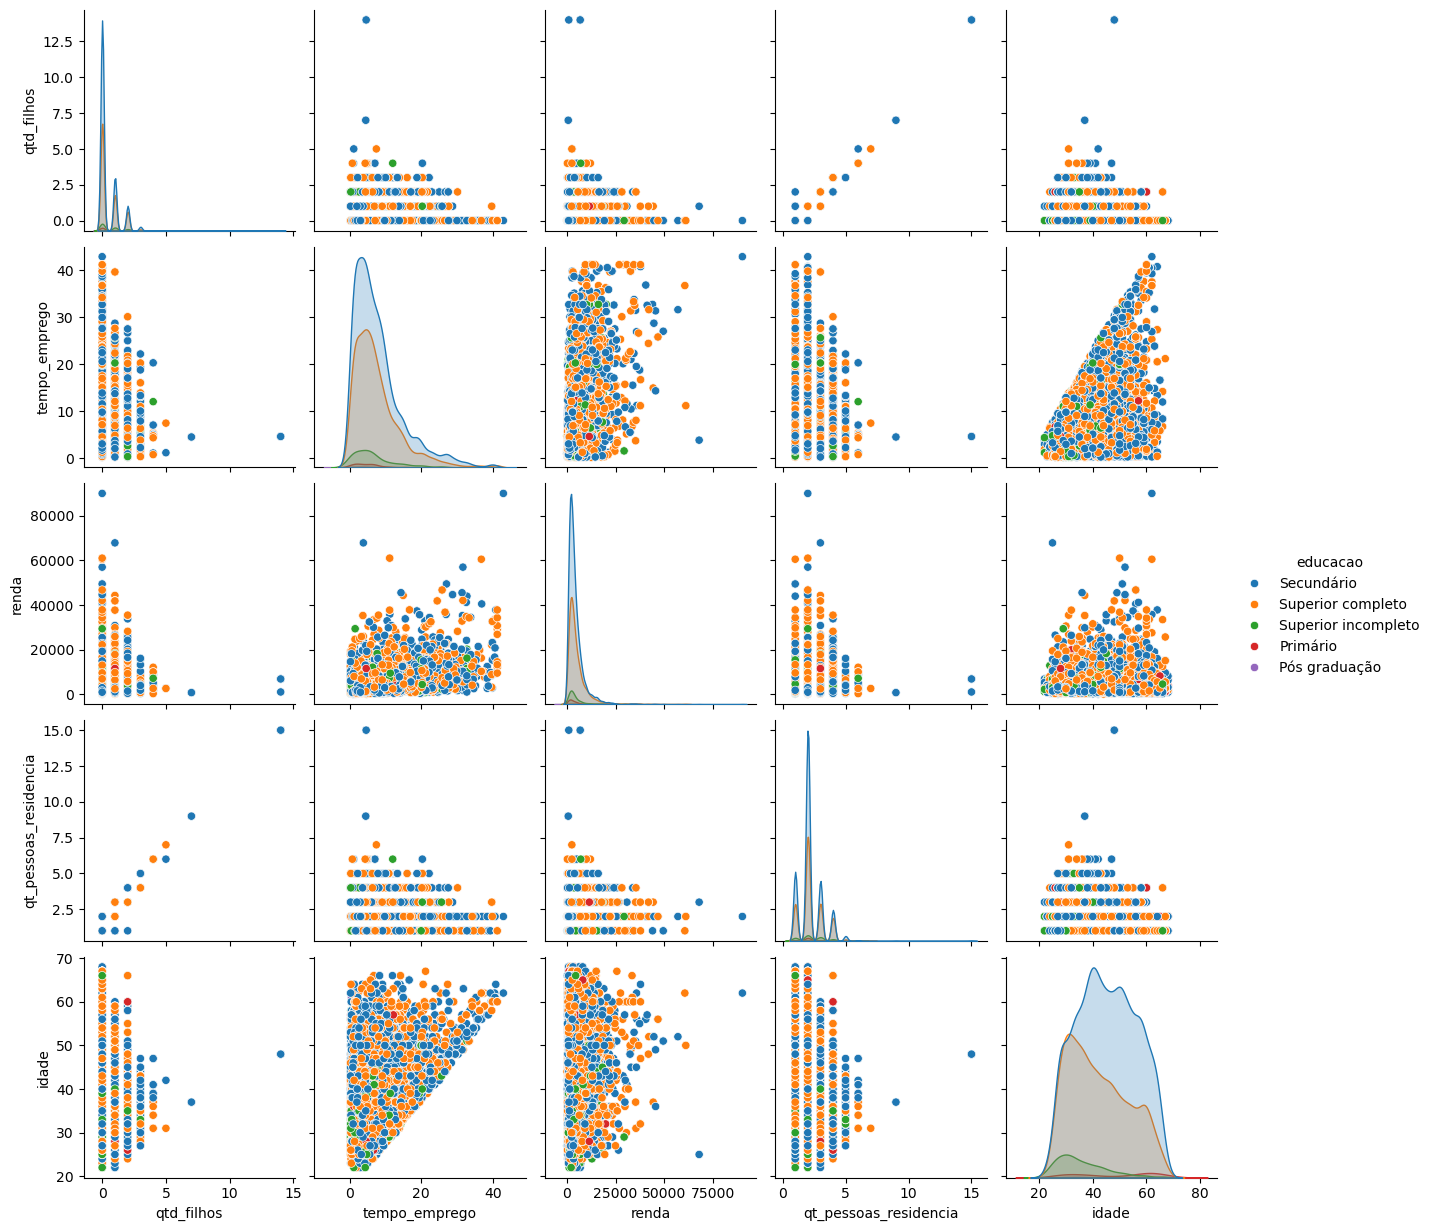

In [91]:
sns.pairplot(previsao_renda, hue='educacao', vars=['qtd_filhos', 'tempo_emprego', 'renda', 'qt_pessoas_residencia', 'idade'])

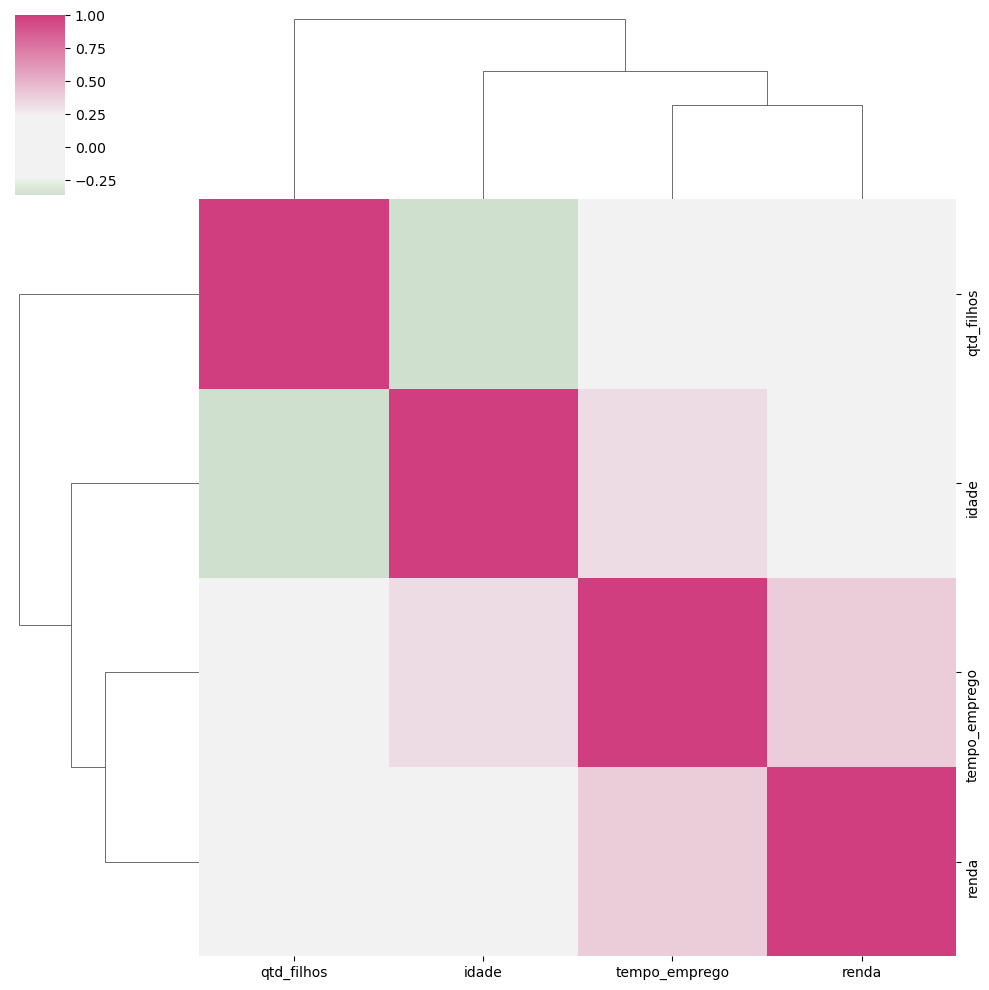

In [93]:
cmap = sns.diverging_palette(h_neg=125, h_pos=350, as_cmap=True, sep=60, center = 'light')
sns.clustermap((previsao_renda_corr.corr()), figsize=(10,10), center=0, cmap=cmap)

2) Avalie um gráfico de dispersão (*scatterplot*) específico para as duas variáveis mais correlacionadas com *renda*.

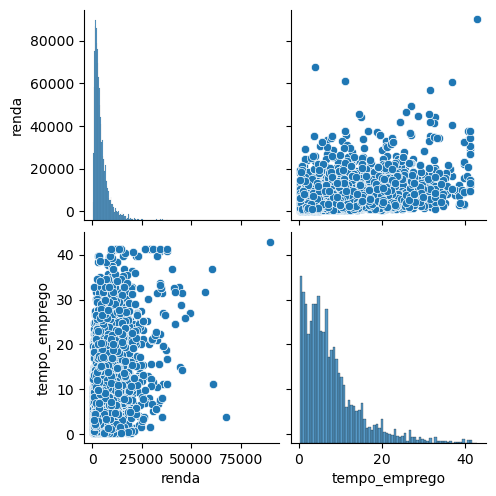

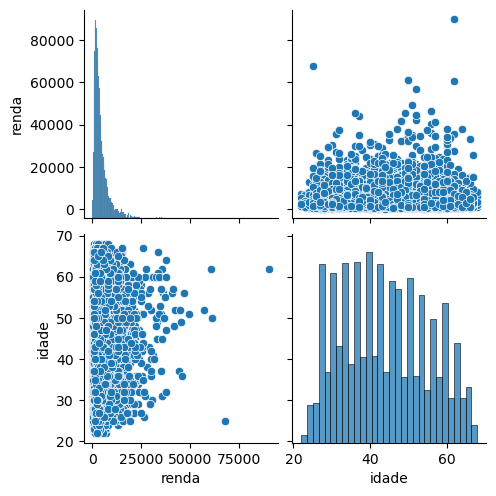

In [109]:
sns.pairplot(previsao_renda_corr, vars=['renda', 'tempo_emprego'])
sns.pairplot(previsao_renda_corr, vars=['renda', 'idade'])

3) Na su aopinião, há outliers na variável renda?

In [ ]:
Sim, há outliers na variavel venda que se destaca tanto na correlação com idade quanto na relação com tempo_emprego.

4) Calcule o logaritmo da variável renda e repita a sequência de análise

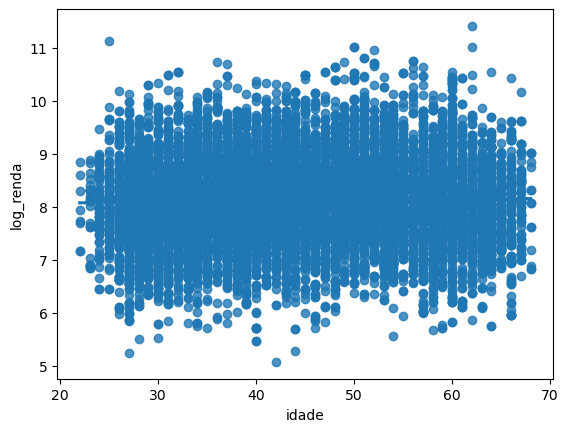

In [111]:
previsao_renda_log = previsao_renda.copy()
previsao_renda_log['log_renda'] = np.log(previsao_renda['renda'])

_=sns.regplot(x='idade', y='log_renda', data=previsao_renda_log)

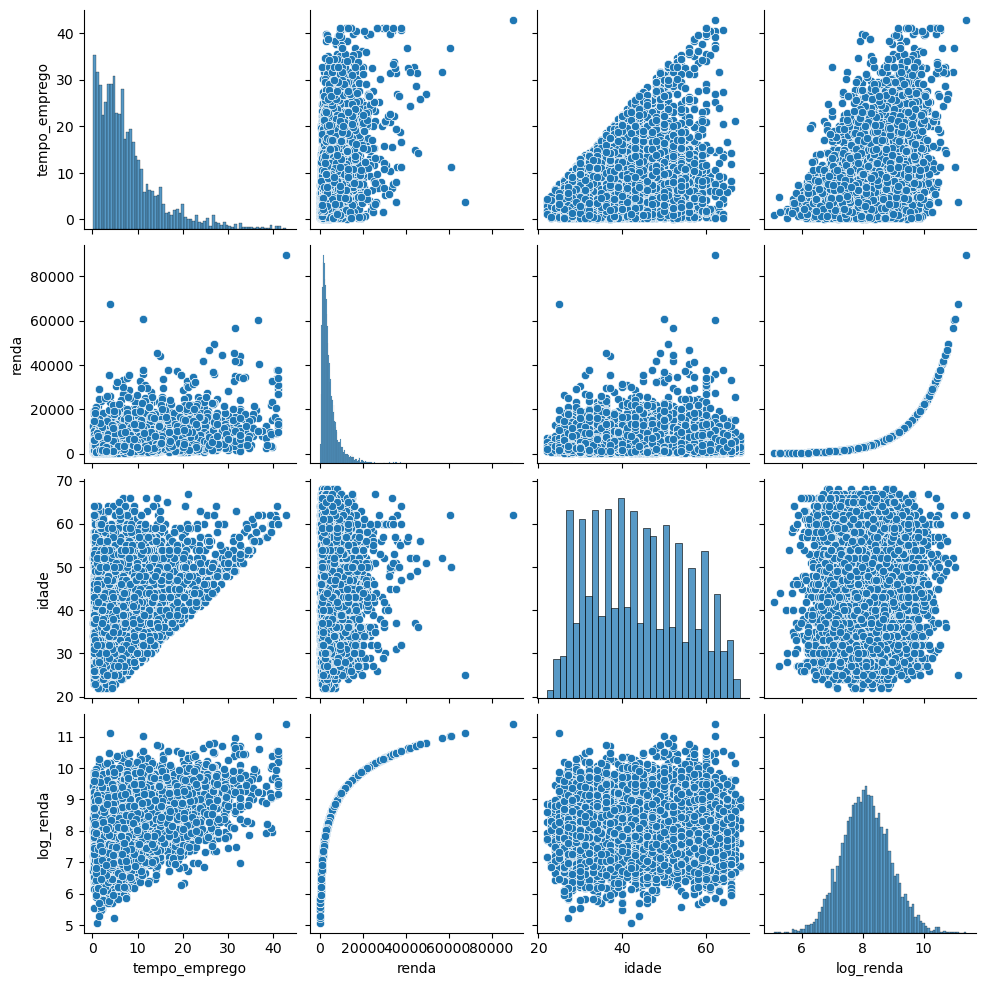

In [115]:
sns.pairplot(previsao_renda_log, vars=['tempo_emprego', 'renda', 'idade', 'log_renda'])

In [119]:
previsao_renda_log[['renda', 'log_renda', 'idade', 'tempo_emprego']].corr()

,renda,log_renda,idade,tempo_emprego
renda,1.000000,0.835734,0.042570,0.394235
log_renda,0.835734,1.000000,0.024712,0.379556
idade,0.042570,0.024712,1.000000,0.323934
tempo_emprego,0.394235,0.379556,0.323934,1.000000


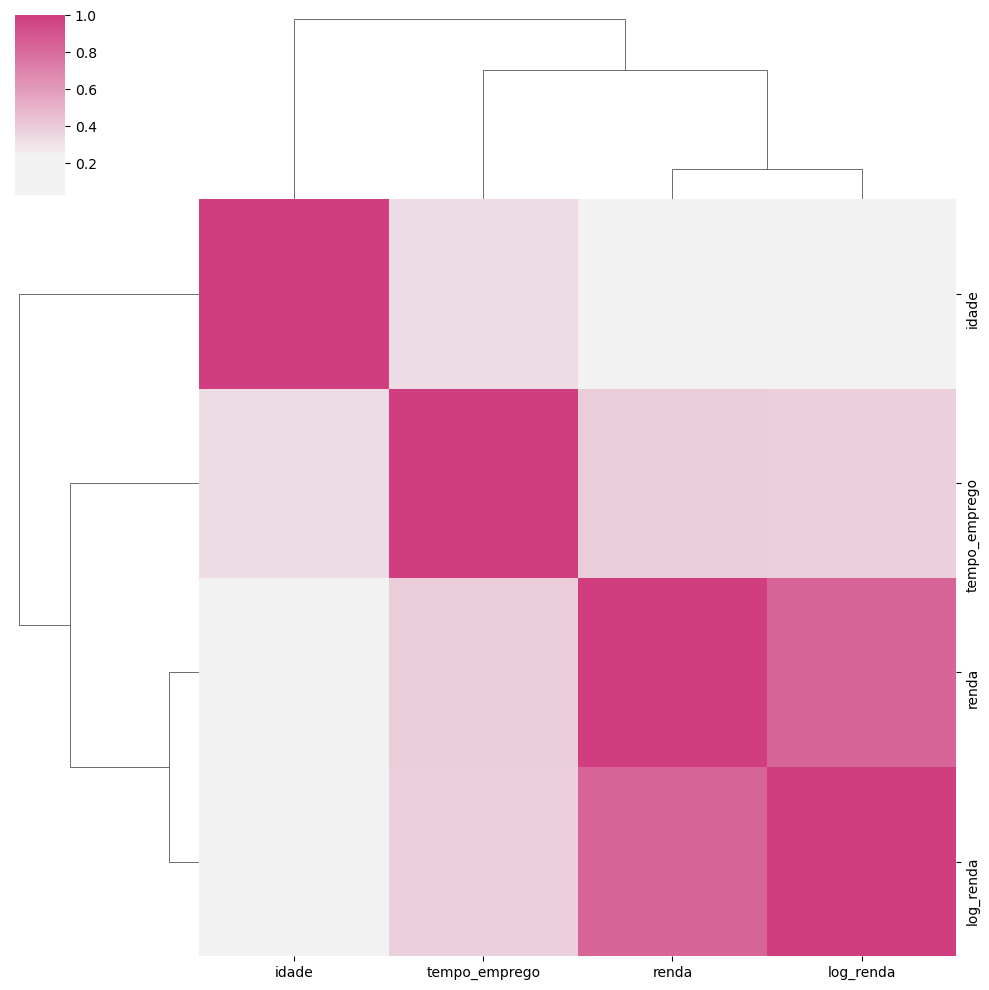

In [123]:
cmap = sns.diverging_palette(h_neg=125, h_pos=350, as_cmap=True, sep=60, center = 'light')
sns.clustermap((previsao_renda_log[['renda', 'log_renda', 'idade', 'tempo_emprego']].corr()), figsize=(10,10), center=0, cmap=cmap)

5) A aplicação do LOG você acha que melhorou ou piorou a análise?

In [ ]:
A analise pelo clusermap indica que a correlação continua a mesma com o tempo emprego quando comparado com log_renda.